# Solving the Assessment - Grid World Problem using Value Iteration

In this notebook, we demonstrate the reusability of our custom `value_iteration` package by applying it to the specific Grid World problem defined in Assessment .

We have set up the rules (the movements and rewards) to match the specific requirements of Assessment. However, because the code is modular (built in separate, flexible pieces), you can easily swap these rules out. You can plug in your own functions to solve many different types of Grid World problems using this same solver.

## What is a Grid World Problem?

A Grid World is a classic environment in Reinforcement Learning and Operational Research used to demonstrate spatial navigation and decision-making under uncertainty. It consists of an $n \times m$ grid of cells where an autonomous agent must learn to navigate towards a specific goal. 

Unlike simple deterministic environments where an action (like "move right") guarantees the intended outcome, the environment in this assessment is **stochastic**. This means the grid has inherent uncertainty, if the agent attempts to move in a particular direction, there is a probability distribution governing where they actually end up (e.g., they might successfully move right, or they might "slip" into an adjacent square). 

The agent's objective is to navigate the grid while accumulating the maximum possible expected reward, carefully balancing the negative fractional costs of moving through dangerous cells against the eventual massive payoff of reaching the goal.

## Modelling the Assessment as a Markov Decision Process (MDP)

To solve this environment using our Value Iteration algorithm, we must mathematically formalize the grid as an MDP. An MDP is defined by the tuple $(S, A, P, R, \gamma)$. 

Here is how the Assessment parameters map to this framework:

* **States ($S$):** The set of all possible positions on our 2x2 grid: $\{TL, TR, BL, BR\}$. State $BR$ is explicitly defined as an absorbing terminal state.
* **Actions ($A$):** The set of possible movements from a given state. Depending on the current state, the available actions are a subset of $\{Up, Down, Left, Right\}$. 
* **Transition Dynamics ($P(s'|s,a)$):** The probability of reaching next state $s'$ given current state $s$ and action $a$. For example, taking action 'Right' from 'TL' has a $0.9$ probability of successfully reaching 'TR', but a $0.1$ probability of slipping into 'BL'.
* **Reward Function ($R(s', s, a)$):** The immediate reward received during a transition. In this specific problem, standard movements incur negative fractional penalties (e.g., $-1.0$, $-3/2$, $-5/2$), while transitioning into the terminal $BR$ state yields high positive rewards ($+10.0$, $+15.0$, $+20.0$).
* **Discount Factor ($\gamma$):** We apply a standard discount factor of $\gamma = 0.9$ to ensure the algorithm converges and to prioritize immediate rewards over distant, uncertain ones.

By passing this mathematical formulation into our solver, we can calculate the optimal policy $\pi^*$.

In [1]:
#Import packages
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
import os

# Ensure the notebook can find the package in the parent directory
sys.path.append(os.path.abspath('..'))

# Import the core solver and the formatting utility
from value_iteration import value_iteration, print_results

# Import the specific problem data generator for Assessment 
from examples.gridworld_generators import get_assessment_grid_world

## Execution

We will now initialize the environment and run the value iteration algorithm. Unless otherwise specified by the environment constraints, we use a standard discount factor ($\gamma = 0.9$) and a strict convergence threshold ($\theta = 10^{-6}$).

In [2]:
# Load the assessment data
states, transitions, terminal_states = get_assessment_grid_world()

# Execute the algorithm
V, policy = value_iteration(
    states=states, 
    transitions=transitions, 
    terminal_states=terminal_states, 
    gamma=0.9
)

# Output the results
print_results(V, policy)
print("Algorithm converged successfully.")

--- Optimal Value Function ---
State TL: 14.8639
State TR: 14.4755
State BL: 19.0877
State BR: 0.0000

--- Optimal Policy ---
State TL: Take action 'D'
State TR: Take action 'D'
State BL: Take action 'R'
State BR: Terminal (No Action)
Algorithm converged successfully.


## Visualising the Results
To better understand the algorithm's output, we map the resulting Value Function ($V$) and Optimal Policy ($\pi^*$) onto a 2D spatial grid.

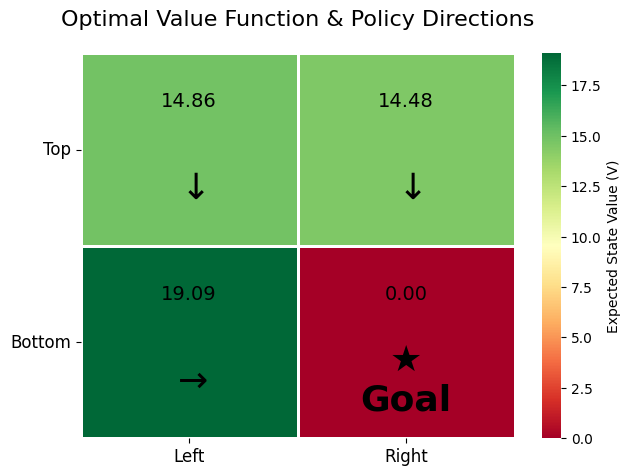

In [4]:
# Map the policy actions to standard directional arrows
arrow_map = {
    'U': r"$\uparrow$", 
    'D': r"$\downarrow$", 
    'L': r"$\leftarrow$", 
    'R': r"$\rightarrow$",
    None: "★\nGoal"
}

# Reshape the flat dictionaries into 2x2 spatial matrices
v_matrix = np.array([
    [V['TL'], V['TR']],
    [V['BL'], V['BR']]
])

policy_matrix = np.array([
    [arrow_map[policy['TL']], arrow_map[policy['TR']]],
    [arrow_map[policy['BL']], arrow_map[policy['BR']]]
])

# Create the visual heatmap 
plt.figure(figsize=(7, 5))
ax = sns.heatmap(v_matrix, cmap="RdYlGn", linewidths=1, annot=False,
                 cbar_kws={'label': 'Expected State Value (V)'})

# Manually overlay the values and arrows to prevent overlapping
for i in range(2):
    for j in range(2):
        # Place the numeric value near the top of the cell
        ax.text(j + 0.5, i + 0.25, f"{v_matrix[i, j]:.2f}",
                ha='center', va='center', fontsize=14, color="black")
        
        # Place the directional arrow near the bottom of the cell
        ax.text(j + 0.5, i + 0.7, policy_matrix[i, j],
                ha='center', va='center', fontsize=26, color="black", fontweight="bold")

# Format the grid appearance
ax.set_xticklabels(['Left', 'Right'], fontsize=12)
ax.set_yticklabels(['Top', 'Bottom'], fontsize=12, rotation=0)
plt.title("Optimal Value Function & Policy Directions", fontsize=16, pad=20)

plt.show()

## Interpreting the Results
The heatmap above clearly illustrates the optimal strategy. The darker green cells represent higher expected future values due to their proximity to the high-reward terminal state (BR). 

The algorithm successfully accounts for the stochastic "slip" probabilities. Rather than taking the shortest physical path, the optimal policy mathematically balances the risk of moving through high-cost penalty zones against the probabilities of successfully reaching the terminal reward.

## Conclusion

This working example successfully demonstrates the implementation of the Value Iteration algorithm to solve a stochastic Grid World problem. 

By deliberately separating the environment dynamics (transition probabilities and rewards) from the core mathematical solver, this package adheres to standard software engineering design principles. The codebase remains modular, robust, and highly reusable for future, more complex Markov Decision Processes.

Furthermore, the heatmap visualization confirms the mathematical accuracy of the algorithm. The optimal policy does not simply draw the shortest physical line to the terminal state; instead, it dynamically balances the expected future rewards against the stochastic risk of "slipping" into high-penalty zones. The algorithm has successfully converged on a policy that maximizes the cumulative discounted reward.